**Task 1 — Google Drive Setup & GPU**|

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import os

# Check what's in your Project folder
path = '/content/drive/MyDrive/Project'
print(os.listdir(path))

['DATASET.zip', 'train_images', 'test_images', 'DATASET']


In [ ]:
# Unzip the dataset directly extracting train_images and test_images
import zipfile
import os

zip_path     = '/content/drive/MyDrive/Project/DATASET.zip'
extract_path = '/content/drive/MyDrive/Project/'

print("Extracting dataset")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    for file in zip_ref.namelist():
        if 'train_images/' in file or 'test_images/' in file:
            zip_ref.extract(file, extract_path)
print("Done")


Extracting dataset
Done


In [ ]:
# Verify
train_path = '/content/drive/MyDrive/Project/train_images'
test_path  = '/content/drive/MyDrive/Project/test_images'

In [ ]:
import os

project_path = '/content/drive/MyDrive/Project'
print("Project folder contains:", os.listdir(project_path))

Project folder contains: ['DATASET.zip', 'train_images', 'test_images', 'DATASET']


In [ ]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

Using device: cpu


**Task 2 - Folder Structure**

In [ ]:
import os

train_path = '/content/drive/MyDrive/Project/train_images'
test_path = '/content/drive/MyDrive/Project/test_images'

print("Train images:", len(os.listdir(train_path)))
print("Test images:", len(os.listdir(test_path)))

Train images: 4166
Test images: 1149


In [ ]:
import os

project_path = '/content/drive/MyDrive/Project'
print("Project folder:", os.listdir(project_path))

# Check if there are subfolders inside train_images
train_path = '/content/drive/MyDrive/Project/train_images'
items = os.listdir(train_path)
print("\nFirst 10 items in train_images:", items[:10])
print("Are these folders or files?")
for item in items[:5]:
    full_path = os.path.join(train_path, item)
    if os.path.isdir(full_path):
        print(f"  {item} is a FOLDER containing:", len(os.listdir(full_path)), "files")
    else:
        print(f"  {item} is a FILE")

Project folder: ['DATASET.zip', 'train_images', 'test_images', 'DATASET']

First 10 items in train_images: ['WOMEN-Dresses-id_00000753-02_2_side.png', 'WOMEN-Dresses-id_00000787-01_7_additional.png', 'WOMEN-Dresses-id_00000791-02_1_front.png', 'WOMEN-Dresses-id_00000731-14_7_additional.png', 'WOMEN-Dresses-id_00000770-02_4_full.png', 'WOMEN-Dresses-id_00000731-05_4_full.png', 'WOMEN-Dresses-id_00000731-04_4_full.png', 'WOMEN-Dresses-id_00000753-02_1_front.png', 'WOMEN-Dresses-id_00000800-01_4_full.png', 'WOMEN-Dresses-id_00000749-02_3_back.png']
Are these folders or files?
  WOMEN-Dresses-id_00000753-02_2_side.png is a FILE
  WOMEN-Dresses-id_00000787-01_7_additional.png is a FILE
  WOMEN-Dresses-id_00000791-02_1_front.png is a FILE
  WOMEN-Dresses-id_00000731-14_7_additional.png is a FILE
  WOMEN-Dresses-id_00000770-02_4_full.png is a FILE


### Verifying Image Paths and Accessibility

In [ ]:
import os
from PIL import Image

# Re-confirm paths (though they should be set from previous cells)
train_path = '/content/drive/MyDrive/Project/train_images'
test_path  = '/content/drive/MyDrive/Project/test_images'

print(f"Checking training image path: {train_path}")
if os.path.exists(train_path):
    print("Train images directory exists.")
    train_images = [f for f in os.listdir(train_path) if f.endswith(('.png', '.jpg', '.jpeg'))]
    print(f"Found {len(train_images)} image files in training directory.")
    if train_images:
        print("Attempting to open first 5 training images...")
        for i, img_name in enumerate(train_images[:5]):
            img_full_path = os.path.join(train_path, img_name)
            try:
                with Image.open(img_full_path) as img:
                    img.verify() # Verify file integrity without loading pixels
                print(f"Image {i+1}: '{img_name}' opened successfully.")
            except (IOError, Image.UnidentifiedImageError) as e:
                print(f"Image {i+1}: '{img_name}' failed to open. Error: {e}")
    else:
        print("No image files found in training directory.")
else:
    print("Train images directory DOES NOT EXIST.")

Checking training image path: /content/drive/MyDrive/Project/train_images
Train images directory exists.
Found 4166 image files in training directory.
Attempting to open first 5 training images...
Image 1: 'WOMEN-Dresses-id_00000753-02_2_side.png' opened successfully.
Image 2: 'WOMEN-Dresses-id_00000787-01_7_additional.png' opened successfully.
Image 3: 'WOMEN-Dresses-id_00000791-02_1_front.png' opened successfully.
Image 4: 'WOMEN-Dresses-id_00000731-14_7_additional.png' opened successfully.
Image 5: 'WOMEN-Dresses-id_00000770-02_4_full.png' opened successfully.


In [ ]:
print(f"\nChecking testing image path: {test_path}")
if os.path.exists(test_path):
    print("Test images directory exists.")
    test_images = [f for f in os.listdir(test_path) if f.endswith(('.png', '.jpg', '.jpeg'))]
    print(f"Found {len(test_images)} image files in testing directory.")
    if test_images:
        print("Attempting to open first 5 testing images...")
        for i, img_name in enumerate(test_images[:5]):
            img_full_path = os.path.join(test_path, img_name)
            try:
                with Image.open(img_full_path) as img:
                    img.verify()
                print(f"Image {i+1}: '{img_name}' opened successfully.")
            except (IOError, Image.UnidentifiedImageError) as e:
                print(f"Image {i+1}: '{img_name}' failed to open. Error: {e}")
    else:
        print("No image files found in testing directory.")
else:
    print("Test images directory DOES NOT EXIST.")


Checking testing image path: /content/drive/MyDrive/Project/test_images
Test images directory exists.
Found 1149 image files in testing directory.
Attempting to open first 5 testing images...
Image 1: 'WOMEN-Blouses_Shirts-id_00000806-02_4_full.png' opened successfully.
Image 2: 'WOMEN-Blouses_Shirts-id_00000997-01_4_full.png' opened successfully.
Image 3: 'WOMEN-Blouses_Shirts-id_00001217-03_4_full.png' opened successfully.
Image 4: 'WOMEN-Blouses_Shirts-id_00000721-03_4_full.png' opened successfully.
Image 5: 'WOMEN-Blouses_Shirts-id_00000890-03_4_full.png' opened successfully.


**Task 3 - Image Transforms & Display**

In [ ]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import os

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

Using device: cpu


In [ ]:
# Check number of channels
sample_img = Image.open(os.path.join(train_path, os.listdir(train_path)[0]))
print("Image mode:", sample_img.mode)

Image mode: RGB


In [ ]:
# Transforms
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

In [ ]:
import os
import random
from PIL import Image

# Redefine paths and subset in case session reset
train_path = '/content/drive/MyDrive/Project/train_images'
test_path  = '/content/drive/MyDrive/Project/test_images'

all_train_images = [f for f in os.listdir(train_path)
                    if f.endswith('.png') or f.endswith('.jpg')]
all_test_images  = [f for f in os.listdir(test_path)
                    if f.endswith('.png') or f.endswith('.jpg')]

random.seed(42)
train_subset = random.sample(all_train_images, min(3000, len(all_train_images)))

print(f"Train subset: {len(train_subset)}")
print(f"Test images : {len(all_test_images)}")

# Dataset class with corrupted image handling
class FashionDataset(Dataset):
    def __init__(self, folder_path, file_list=None, transform=None):
        self.folder_path = folder_path
        self.transform   = transform

        if file_list:
            all_files = file_list
        else:
            all_files = [f for f in os.listdir(folder_path)
                        if f.endswith('.png') or f.endswith('.jpg')]

        print("Checking images...")
        self.images = []
        for f in all_files:
            try:
                img_path = os.path.join(folder_path, f)
                Image.open(img_path).verify()
                self.images.append(f)
            except:
                print(f"Skipping corrupted image: {f}")

        print(f"Valid images: {len(self.images)}")

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.folder_path, self.images[idx])
        image    = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image

# Reload datasets
train_dataset = FashionDataset(train_path, file_list=train_subset,    transform=transform)
test_dataset  = FashionDataset(test_path,  file_list=all_test_images, transform=transform)

print("Train dataset size:", len(train_dataset))
print("Test dataset size :", len(test_dataset))

Train subset: 3000
Test images : 1149
Checking images...
Skipping corrupted image: WOMEN-Dresses-id_00005102-02_2_side.png
Valid images: 2999
Checking images...
Skipping corrupted image: WOMEN-Tees_Tanks-id_00005085-08_4_full.png
Skipping corrupted image: WOMEN-Tees_Tanks-id_00006066-03_4_full.png
Valid images: 1147
Train dataset size: 2999
Test dataset size : 1147


In [ ]:
# Dataset class with corrupted image handling
class FashionDataset(Dataset):
    def __init__(self, folder_path, file_list=None, transform=None):
        self.folder_path = folder_path
        self.transform   = transform

        if file_list:
            all_files = file_list
        else:
            all_files = [f for f in os.listdir(folder_path)
                        if f.endswith('.png') or f.endswith('.jpg')]

        # Filter out corrupted images
        print("Checking images...")
        self.images = []
        for f in all_files:
            try:
                img_path = os.path.join(folder_path, f)
                Image.open(img_path).verify()  # verify it's a valid image
                self.images.append(f)
            except:
                print(f"Skipping corrupted image: {f}")

        print(f"Valid images: {len(self.images)}")

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.folder_path, self.images[idx])
        image    = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image

# Reload datasets with fixed class
train_dataset = FashionDataset(train_path, file_list=train_subset,    transform=transform)
test_dataset  = FashionDataset(test_path,  file_list=all_test_images, transform=transform)

print("Train dataset size:", len(train_dataset))
print("Test dataset size :", len(test_dataset))


Checking images...
Skipping corrupted image: WOMEN-Dresses-id_00005102-02_2_side.png
Valid images: 2999
Checking images...
Valid images: 1149
Train dataset size: 2999
Test dataset size : 1149


In [ ]:
# Load datasets
train_dataset = FashionDataset(train_path, transform=transform)
test_dataset = FashionDataset(test_path, transform=transform)


Checking images...
Skipping corrupted image: WOMEN-Dresses-id_00005102-02_2_side.png
Valid images: 4165
Checking images...
Valid images: 1149


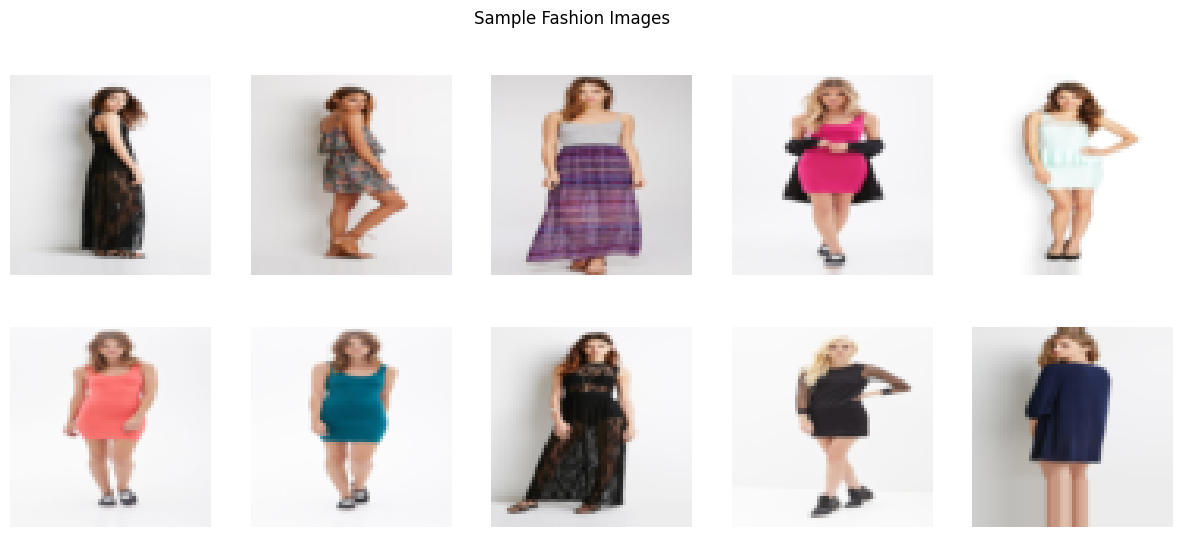

In [ ]:
# Display 2 rows 5 columns
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flat):
    img = train_dataset[i]
    img = img * 0.5 + 0.5
    img = img.permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.axis('off')
plt.suptitle('Sample Fashion Images')
plt.show()

**Task 4 - DataLoader**

In [ ]:
# Task 4: Load dataset using DataLoader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

print("Train batches:", len(train_loader))
print("Test batches:", len(test_loader))

Train batches: 131
Test batches: 36


**Task 5 - CVAE Model + Training**

In [ ]:
# Task 5: Convolutional VAE Architecture

class CVAE(nn.Module):
    def __init__(self, latent_dim=128):
        super(CVAE, self).__init__()

        # Encoder - 3 Conv2d layers
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=4, stride=2, padding=1),   # 64->32
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),  # 32->16
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1), # 16->8
            nn.ReLU()
        )

        # Dense layers for mu and logvar
        self.fc_mu = nn.Linear(128 * 8 * 8, latent_dim)
        self.fc_logvar = nn.Linear(128 * 8 * 8, latent_dim)

        # Decoder input
        self.fc_decode = nn.Linear(latent_dim, 128 * 8 * 8)

        # Decoder - 3 ConvTranspose2d layers
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1), # 8->16
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),  # 16->32
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, kernel_size=4, stride=2, padding=1),   # 32->64
            nn.Tanh()
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        # Encode
        x = self.encoder(x)
        x = x.view(x.size(0), -1)
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)

        # Reparameterize
        z = self.reparameterize(mu, logvar)

        # Decode
        x = self.fc_decode(z)
        x = x.view(x.size(0), 128, 8, 8)
        x = self.decoder(x)
        return x, mu, logvar

In [ ]:
# Loss function
def vae_loss(reconstructed, original, mu, logvar):
    mse_loss = nn.MSELoss()(reconstructed, original)
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    kl_loss = kl_loss / original.size(0)
    return mse_loss + kl_loss * 0.001


In [ ]:
# Initialize model, optimizer
model = CVAE(latent_dim=128).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


In [ ]:
# Train for 10 epochs
print("Starting training")
for epoch in range(10):
    model.train()
    total_loss = 0
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        reconstructed, mu, logvar = model(batch)
        loss = vae_loss(reconstructed, batch, mu, logvar)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}/10 - Loss: {total_loss/len(train_loader):.4f}")

print("Training done!")

Starting training
Epoch 1/10 - Loss: 0.1738
Epoch 2/10 - Loss: 0.1173
Epoch 3/10 - Loss: 0.1002
Epoch 4/10 - Loss: 0.0932
Epoch 5/10 - Loss: 0.0863
Epoch 6/10 - Loss: 0.0822
Epoch 7/10 - Loss: 0.0794
Epoch 8/10 - Loss: 0.0774
Epoch 9/10 - Loss: 0.0766
Epoch 10/10 - Loss: 0.0752
Training done!


**Task 5 g - Show Reconstruction Images**

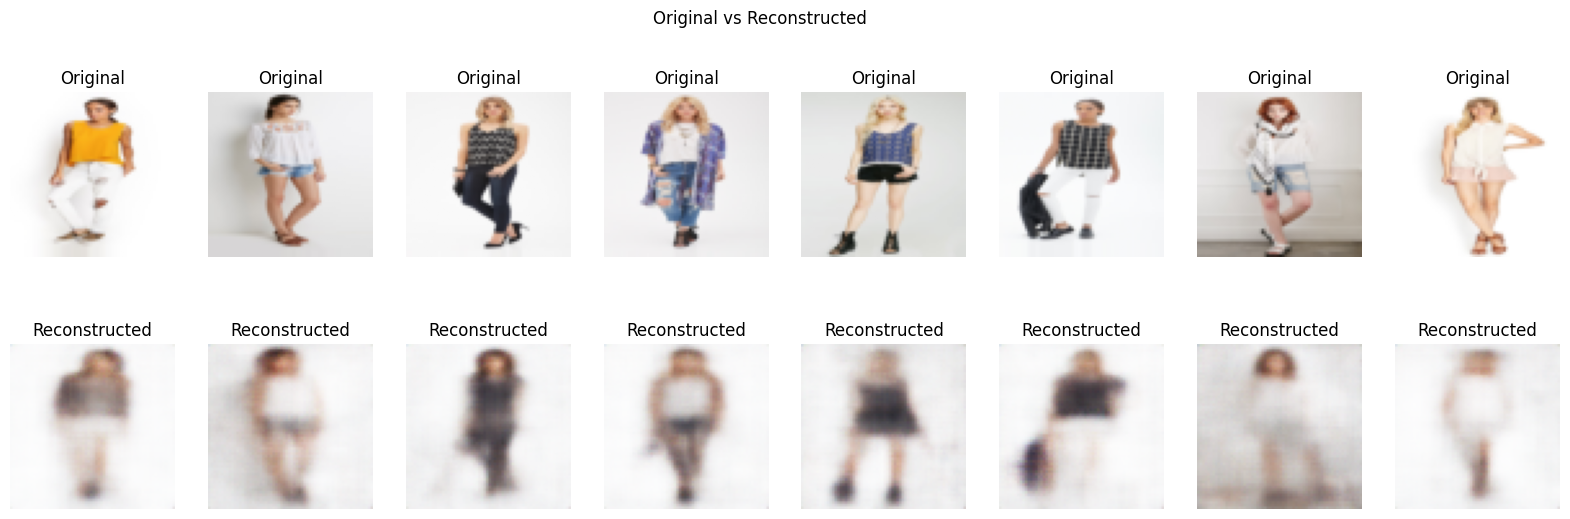

In [ ]:
# Task 5g: Show original vs reconstructed images (2 rows, 8 columns)
model.eval()
test_batch = next(iter(test_loader))
test_batch = test_batch.to(device)

with torch.no_grad():
    reconstructed, _, _ = model(test_batch)

fig, axes = plt.subplots(2, 8, figsize=(20, 6))

for i in range(8):
    # Row 1 - original
    img = test_batch[i].cpu() * 0.5 + 0.5
    axes[0, i].imshow(img.permute(1, 2, 0).numpy())
    axes[0, i].axis('off')
    axes[0, i].set_title('Original')

    # Row 2 - reconstructed
    img = reconstructed[i].cpu() * 0.5 + 0.5
    axes[1, i].imshow(img.permute(1, 2, 0).numpy())
    axes[1, i].axis('off')
    axes[1, i].set_title('Reconstructed')

plt.suptitle('Original vs Reconstructed')
plt.show()

**Task 6 - Save, Load and Generate**

In [ ]:
# Task 6: Save model
torch.save(model.state_dict(), '/content/drive/MyDrive/Project/cvae_model.pth')
print("Model saved")

Model saved


In [ ]:
# Load model
loaded_model = CVAE(latent_dim=128).to(device)
loaded_model.load_state_dict(torch.load('/content/drive/MyDrive/Project/cvae_model.pth'))
loaded_model.eval()
print("Model loaded")

Model loaded


In [ ]:
# Generate synthetic fashion image
with torch.no_grad():
    z = torch.randn(1, 128).to(device)
    z = loaded_model.fc_decode(z)
    z = z.view(1, 128, 8, 8)
    synthetic_image = loaded_model.decoder(z)

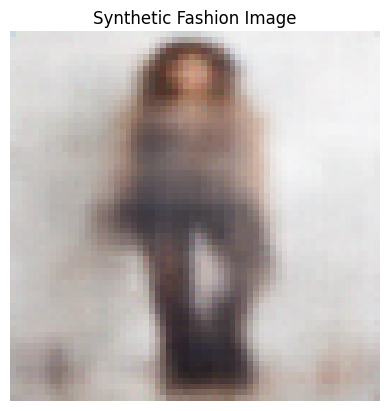

In [ ]:
# Display generated image
img = synthetic_image[0].cpu() * 0.5 + 0.5
plt.imshow(img.permute(1, 2, 0).numpy())
plt.title('Synthetic Fashion Image')
plt.axis('off')
plt.show()

**Inference (Load saved model & Generate image)**

Model loaded successfully!


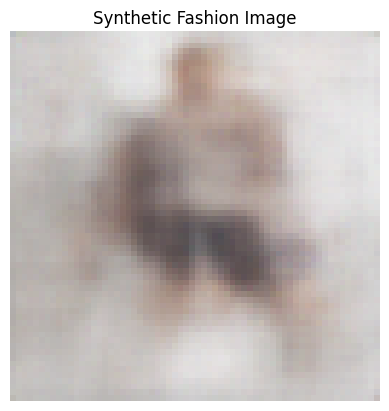

In [ ]:
# Load saved model
loaded_model = CVAE(latent_dim=128).to(device)
loaded_model.load_state_dict(torch.load('/content/drive/MyDrive/Project/cvae_model.pth',
                                         map_location=device))
loaded_model.eval()
print("Model loaded successfully!")

# Generate synthetic fashion image
with torch.no_grad():
    z               = torch.randn(1, 128).to(device)
    z               = loaded_model.fc_decode(z)
    z               = z.view(1, 128, 8, 8)
    synthetic_image = loaded_model.decoder(z)

img = synthetic_image[0].cpu() * 0.5 + 0.5
plt.imshow(img.permute(1, 2, 0).numpy())
plt.title('Synthetic Fashion Image')
plt.axis('off')
plt.show()